In [1]:
import numpy as np
import pandas as pd
import h5py
import os, sys
import torch
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score
from typing import Dict, List
sys.path.append('../')
from config import JUNCTIONS, get_file_paths, get_file_paths_list, reverse_complement
from get_logits import *

In [2]:
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [3]:
labels_dict = {}
for idx, junction in enumerate(JUNCTIONS):
    label = pd.read_csv(get_file_paths('labels', '../../../results/pseudo_gene/splice_junctions/')[junction], sep='\t')
    for model in ['pcv1', 'pcv2_1', 'pcv2_2', 'pcv2_3', 'evo2_fwd', 'evo2_rc', 'gpn']:
        scores = get_averaged_probs(model, idx, tokenizer, base_dir='../../../results/pseudo_gene/outputs/', chunk_size=None, JUNCTIONS=JUNCTIONS)
        label[f'{model}_scores'] = scores

    if junction in ['start_sites', 'acceptor']:
        label['evo2_scores'] = label['evo2_rc_scores']
    else:
        label['evo2_scores'] = label['evo2_fwd_scores']
        
    labels_dict[junction] = label

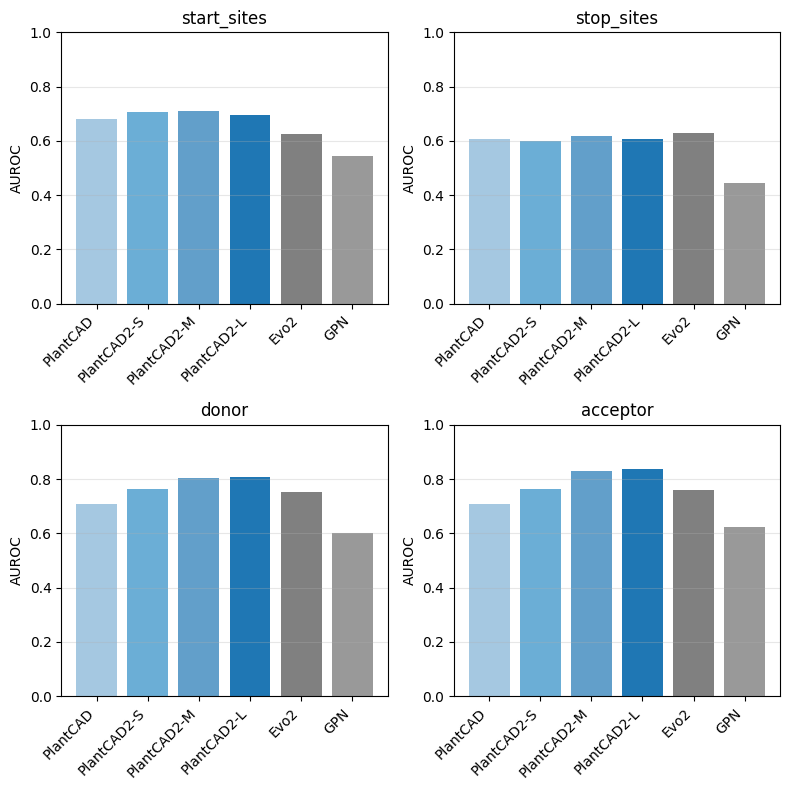

In [4]:
colors = ['#1f77b466', '#6baed6', '#1f77b4b3', '#1f77b4ff',  '#808080', '#999999', '#d3d3d3']

model_preds = [
    ('pcv1_scores', 'PlantCAD'),
    ('pcv2_1_scores', 'PlantCAD2-S'),
    ('pcv2_2_scores', 'PlantCAD2-M'),
    ('pcv2_3_scores', 'PlantCAD2-L'),
    ('evo2_scores', 'Evo2'),
    ('gpn_scores', 'GPN'),
]
colors_use = colors[:len(model_preds)]
model_labels = [lbl for _, lbl in model_preds]

def to_binary(label_str):
    # 1 = Core, 0 = non-Core; ignore "Near-Core Gene"
    return 1 if ('Core' in label_str and 'Near' not in label_str) else 0

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes_flat = axes.flatten()

for idx, (dataset_name, df) in enumerate(labels_dict.items()):
    ax = axes_flat[idx]

    # filter & binarize
    subsets = df[df['Label'] != 'Near-Core Gene'].copy()
    y_true = subsets['Label'].apply(to_binary).values

    # handle degenerate case
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, 'Only one class present', ha='center', va='center')
        ax.set_axis_off()
        continue

    # compute AUROC per model
    aurocs = []
    for pred_col, _ in model_preds:
        y_scores = subsets[pred_col].values
        aurocs.append(roc_auc_score(y_true, y_scores))

    # barplot
    x = np.arange(len(model_preds))
    ax.bar(x, aurocs, color=colors_use, width=0.8)

    # cosmetics
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylabel('AUROC')
    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=45, ha='right')
    ax.set_ylim(0, 1.0)

    # annotate values
    # for i, v in enumerate(aurocs):
    #     ax.text(i, min(v + 0.02, 1.02), f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.15, wspace=0.3, hspace=0.4)
plt.tight_layout()
plt.savefig('Core_noncore_AUROC_bars.pdf', format='pdf', bbox_inches='tight')
plt.show()

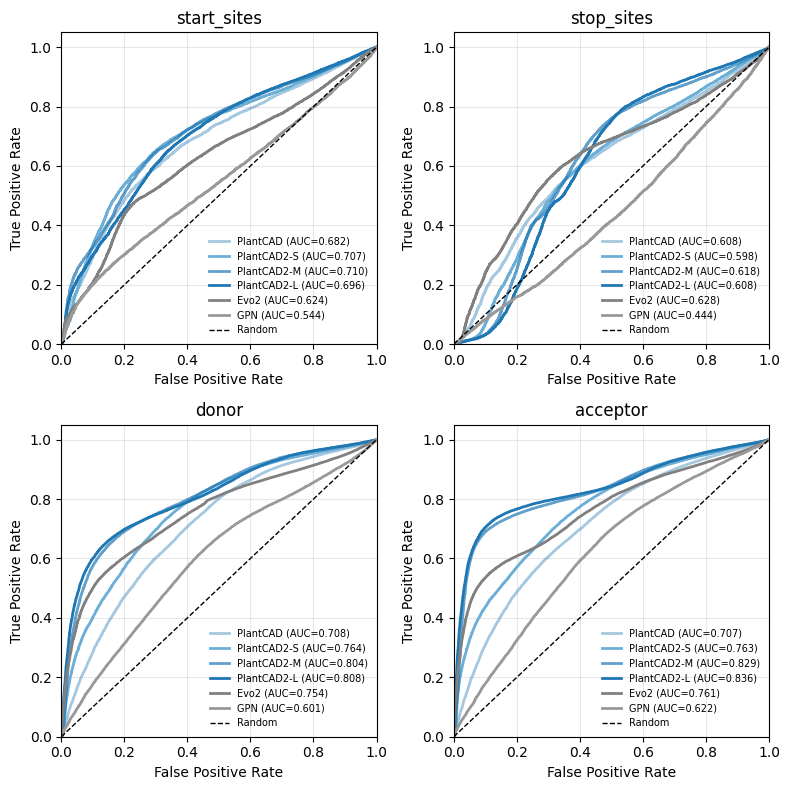

In [5]:
colors = ['#1f77b466', '#6baed6', '#1f77b4b3', '#1f77b4ff',  '#808080', '#999999', '#d3d3d3']

model_preds = [
    ('pcv1_scores', 'PlantCAD'),
    ('pcv2_1_scores', 'PlantCAD2-S'),
    ('pcv2_2_scores', 'PlantCAD2-M'),
    ('pcv2_3_scores', 'PlantCAD2-L'),
    ('evo2_scores', 'Evo2'),
    ('gpn_scores', 'GPN'),
]
colors_use = colors[:len(model_preds)]
model_labels = [lbl for _, lbl in model_preds]

def to_binary(label_str):
    # 1 = Core, 0 = non-Core; ignore "Near-Core Gene"
    return 1 if ('Core' in label_str and 'Near' not in label_str) else 0

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes_flat = axes.flatten()

for idx, (dataset_name, df) in enumerate(labels_dict.items()):
    ax = axes_flat[idx]

    # filter & binarize
    subsets = df[df['Label'] != 'Near-Core Gene'].copy()
    y_true = subsets['Label'].apply(to_binary).values

    # handle degenerate case
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, 'Only one class present', ha='center', va='center')
        ax.set_axis_off()
        continue

    # ROC for each model
    for (pred_col, label), color in zip(model_preds, colors_use):
        y_scores = subsets[pred_col].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.3f})',
                linewidth=2, color=color)

    # diagonal + cosmetics
    ax.plot([0, 1], [0, 1], linestyle='--', color='k', linewidth=1, label='Random')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(dataset_name)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=7, frameon=False)

plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.12, wspace=0.3, hspace=0.35)
plt.tight_layout()
plt.savefig('Core_noncore_ROC_panels.pdf', format='pdf', bbox_inches='tight')
plt.show()